In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import polars as pl
import seaborn as sns
from lightgbm import LGBMClassifier
from scipy.stats import kurtosis, skew
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, make_scorer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.svm import SVC
from typing import Dict, List, Tuple
from xgboost import XGBClassifier, XGBRegressor

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

labels_dict = {
    0: {
        'name': 'Deceased',
        'color': 'r',
        'marker': '^'
    },
    1: {
        'name': 'Survived',
        'color': 'b',
        'marker': 'o'
    }
}

df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

## Data Analysis

In [58]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [59]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [60]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [61]:
# need to handle missing data
df_train.isna().sum() / len(df_train['Survived'])

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [62]:
# need to handle missing data
df_test.isna().sum() / len(df_test['PassengerId'])

PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.205742
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.002392
Cabin          0.782297
Embarked       0.000000
dtype: float64

In [63]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [64]:
print(df_train["Name"].str.extract(r',[^.]*\b(\w+)\.').iloc[:,0].unique())
print(df_test["Name"].str.extract(r',[^.]*\b(\w+)\.').iloc[:,0].unique())

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']
['Mr' 'Mrs' 'Miss' 'Master' 'Ms' 'Col' 'Rev' 'Dr' 'Dona']


In [65]:
df_test[df_test['Fare'].isna()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


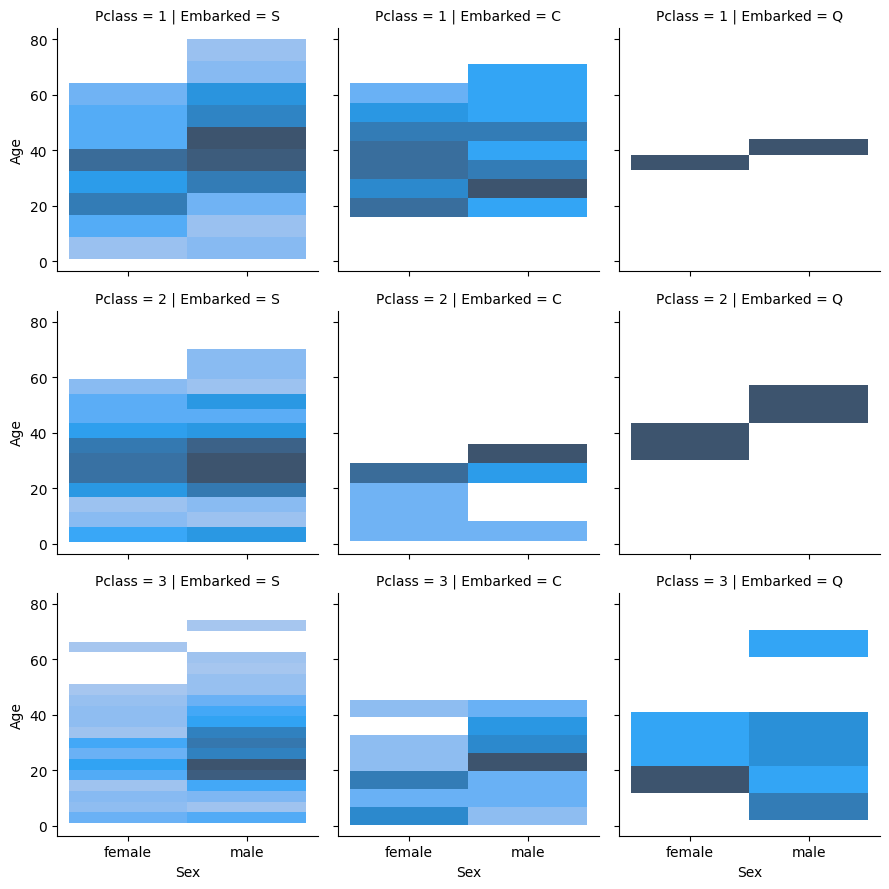

In [66]:
g = sns.FacetGrid(
    data=df_train
    , row='Pclass'
    , col='Embarked'
)

g.map(
    sns.histplot
    , 'Sex'
    , 'Age'
)

# majority of men that embarked on S/Southamton bought cheap tickets
plt.show()

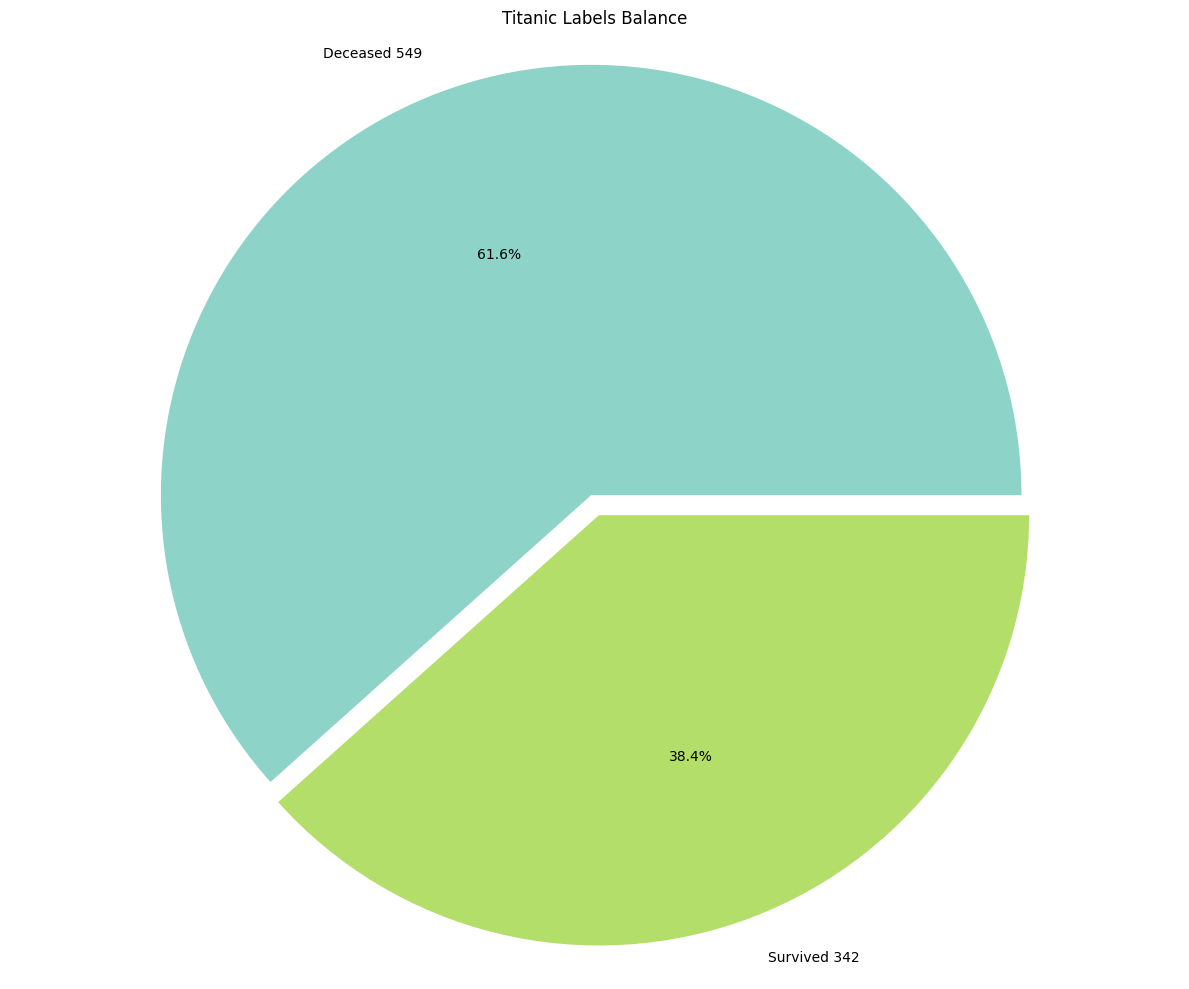

In [67]:
def get_label_balance(label_column: pd.Series, should_return_label_counts=False) -> pd.Series:
        label_counts = label_column.value_counts().sort_index(ascending=True)
        num_labels = len(labels_dict.keys())
        labels = [f"{labels_dict.get(i).get('name')} {label_counts.loc[i]}" for i in range(num_labels)]
        cmap = plt.get_cmap('Set3')
        colors = [cmap(i / num_labels) for i in range(num_labels)]
        plt.figure(figsize=(12, 10))
        plt.pie(label_counts, labels=labels, autopct='%1.1f%%', colors=colors, explode=[0.05, 0])
        plt.title('Titanic Labels Balance')
        plt.axis('equal')
        plt.tight_layout()
        plt.show()
        return label_counts if should_return_label_counts else None

get_label_balance(df_train['Survived'])

In [68]:
df_num = df_train[['Age','SibSp','Parch','Fare']]
df_cat = df_train[['Survived','Pclass','Sex','Ticket','Cabin','Embarked']]

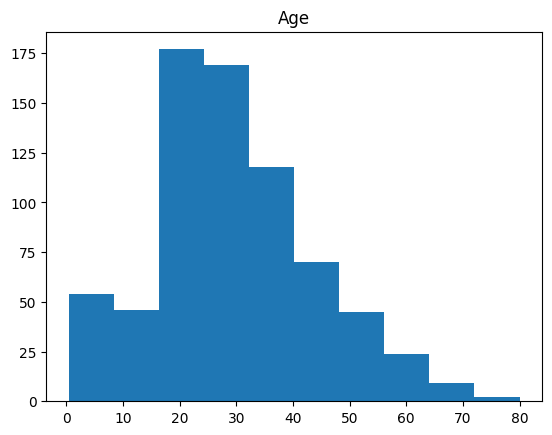

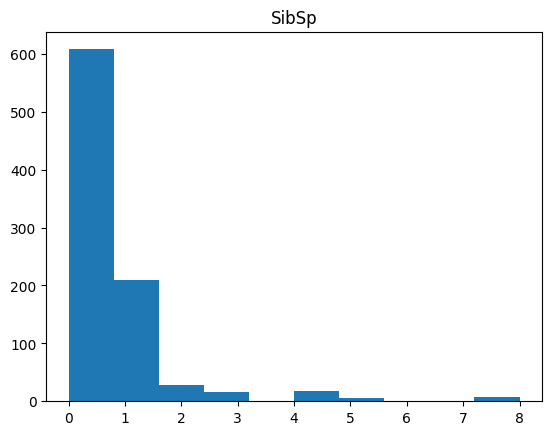

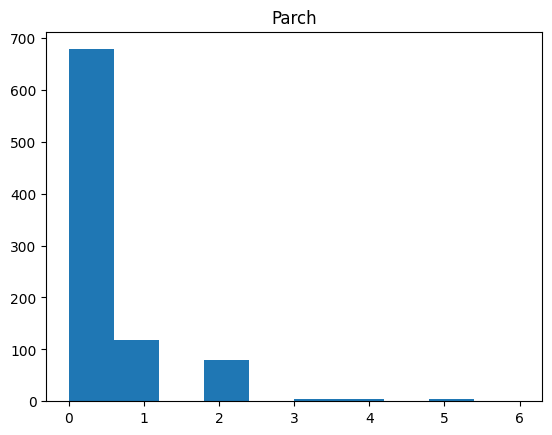

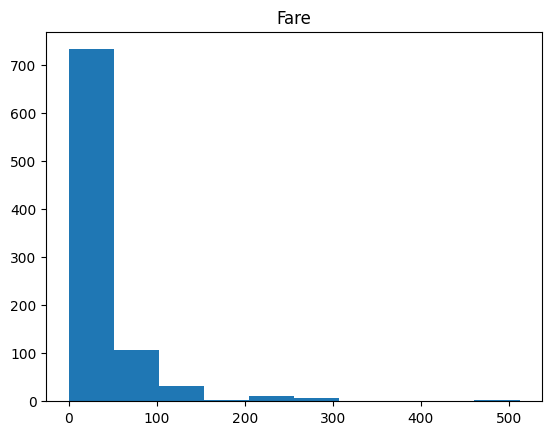

In [69]:
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

            Age     SibSp     Parch      Fare
Age    1.000000 -0.308247 -0.189119  0.096067
SibSp -0.308247  1.000000  0.414838  0.159651
Parch -0.189119  0.414838  1.000000  0.216225
Fare   0.096067  0.159651  0.216225  1.000000


<Axes: >

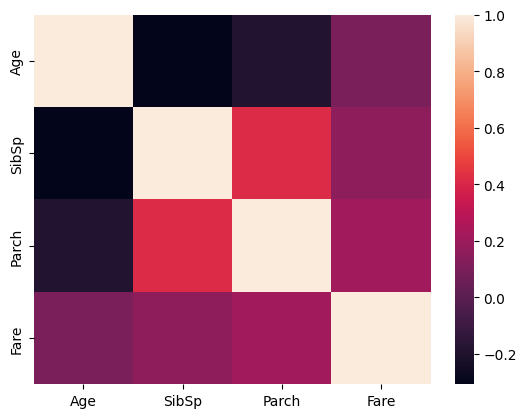

In [70]:
print(df_num.corr())
sns.heatmap(df_num.corr())

In [71]:
# compare survival rate across Age, SibSp, Parch, and Fare 
pd.pivot_table(df_train, index = 'Survived', values = ['Age','SibSp','Parch','Fare'])

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.626179,22.117887,0.329690,0.553734
1,28.343690,48.395408,0.464912,0.473684


## Feature Engineering

In [72]:
# add a title feature

df_train['Title'] = df_train['Name'].str.extract(r',[^.]*\b(\w+)\.')
df_test['Title'] = df_test['Name'].str.extract(r',[^.]*\b(\w+)\.')

df_train['Title'] = df_train['Title'].replace('Mlle', 'Miss')
df_train['Title'] = df_train['Title'].replace('Ms', 'Miss')
df_train['Title'] = df_train['Title'].replace('Mme', 'Mrs')
df_test['Title'] = df_test['Title'].replace('Mlle', 'Miss')
df_test['Title'] = df_test['Title'].replace('Ms', 'Miss')
df_test['Title'] = df_test['Title'].replace('Mme', 'Mrs')

wealth_titles = ['Sir', 'Lady', 'Countess', 'Don', 'Dona', 'Jonkheer']
military_titles = ['Capt', 'Col', 'Major']
professional_titles = ['Dr', 'Rev']

def get_title_status(title):
    if title in wealth_titles:
        return 'Wealthy'
    elif title in military_titles:
        return 'Military'
    elif title in professional_titles:
        return 'Professional'
    elif title in ['Mr', 'Mrs', 'Miss', 'Master']:
        return 'Common'
    else:
        return 'Other'

df_train['TitleStatus'] = df_train['Title'].apply(get_title_status)
df_test['TitleStatus'] = df_test['Title'].apply(get_title_status)

# rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
# df_train['Title'] = df_train['Title'].replace(rare_titles, 'Rare')
# df_test['Title'] = df_test['Title'].replace(rare_titles, 'Rare')

In [73]:
# add family size feature
# in case there is a correlation between survival and family size

df_train_family_size = df_train.copy()
df_train_family_size['FamilySize'] = df_train_family_size['Parch'] + df_train_family_size['SibSp']

df_test_family_size = df_test.copy()
df_test_family_size['FamilySize'] = df_test_family_size['Parch'] + df_test_family_size['SibSp']

# add is alone feature
# in case there is a correlation between survival and if they are alone

df_train_family_size['IsAlone'] = (df_train_family_size['FamilySize'] == 0).astype(int)
df_test_family_size['IsAlone'] = (df_test_family_size['FamilySize'] == 0).astype(int)

In [74]:
# convert Cabin feature into CabinDeck
# makes it a categorical feature

df_train_family_size['CabinDeck'] = df_train_family_size['Cabin'].str[0]
df_train_family_size['HasCabin'] = df_train_family_size['Cabin'].notna().astype(int)

df_test_family_size['CabinDeck'] = df_test_family_size['Cabin'].str[0]
df_test_family_size['HasCabin'] = df_test_family_size['Cabin'].notna().astype(int)

In [75]:
df_train_family_size['CabinCount'] = df_train_family_size.Cabin.apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))
df_test_family_size['CabinCount'] = df_test_family_size.Cabin.apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))

In [76]:
# add TicketGroupSize feature
# shows how many samples have the same ticket

df_train_family_size = df_train_family_size.copy()
df_train_family_size['TicketGroupSize'] = df_train_family_size.groupby('Ticket')['Ticket'].transform('count')

df_test_family_size = df_test_family_size.copy()
df_test_family_size['TicketGroupSize'] = df_test_family_size.groupby('Ticket')['Ticket'].transform('count')

In [ ]:
df_train_family_size['IsNumericTicket'] = df_train_family_size['Ticket'].apply(lambda x: 1 if x.isnumeric() else 0)
df_test_family_size['IsNumericTicket'] = df_test_family_size['Ticket'].apply(lambda x: 1 if x.isnumeric() else 0)

In [78]:
df_train_family_size.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Name             891 non-null    object 
 4   Sex              891 non-null    object 
 5   Age              714 non-null    float64
 6   SibSp            891 non-null    int64  
 7   Parch            891 non-null    int64  
 8   Ticket           891 non-null    object 
 9   Fare             891 non-null    float64
 10  Cabin            204 non-null    object 
 11  Embarked         889 non-null    object 
 12  Title            891 non-null    object 
 13  TitleStatus      891 non-null    object 
 14  FamilySize       891 non-null    int64  
 15  IsAlone          891 non-null    int64  
 16  CabinDeck        204 non-null    object 
 17  HasCabin        

In [79]:
df_test_family_size.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      418 non-null    int64  
 1   Pclass           418 non-null    int64  
 2   Name             418 non-null    object 
 3   Sex              418 non-null    object 
 4   Age              332 non-null    float64
 5   SibSp            418 non-null    int64  
 6   Parch            418 non-null    int64  
 7   Ticket           418 non-null    object 
 8   Fare             417 non-null    float64
 9   Cabin            91 non-null     object 
 10  Embarked         418 non-null    object 
 11  Title            418 non-null    object 
 12  TitleStatus      418 non-null    object 
 13  FamilySize       418 non-null    int64  
 14  IsAlone          418 non-null    int64  
 15  CabinDeck        91 non-null     object 
 16  HasCabin         418 non-null    int64  
 17  CabinCount      

In [80]:
# fill Embarked nan values now to avoid headache of doing it after mapping
# going to replace missing data with most common value

most_embarked = df_train['Embarked'].mode().loc[0]
df_train_family_size['Embarked'] = df_train_family_size['Embarked'].fillna(most_embarked)

In [81]:
# fill Fare nan value in test data now to avoid headache of doing it later
# going to replace it with average value

average_fare = df_train['Fare'].mean()
df_test_family_size['Fare'] = df_test_family_size['Fare'].fillna(average_fare)

In [82]:
# add FarePerPerson feature
# shows how much a person paid for a group ticket

df_train_family_size['FarePerPerson'] = df_train_family_size['Fare'] / df_train_family_size['TicketGroupSize']
df_test_family_size['FarePerPerson'] = df_test_family_size['Fare'] / df_test_family_size['TicketGroupSize']

df_train_family_size['FareBin'] = pd.qcut(df_train_family_size['FarePerPerson'], 5, labels=False)
df_test_family_size['FareBin'] = pd.qcut(df_test_family_size['FarePerPerson'], 5, labels=False)

In [83]:
df_train_family_size['IsMale'] = (df_train_family_size['Sex'] == 'male').astype(int)
df_test_family_size['IsMale'] = (df_test_family_size['Sex'] == 'male').astype(int)

In [84]:
df_train_family_size['Pclass_Sex'] = df_train_family_size['Pclass'].astype(str) + '_' + df_train_family_size['Sex']
df_test_family_size['Pclass_Sex'] = df_test_family_size['Pclass'].astype(str) + '_' + df_test_family_size['Sex']

In [85]:
df_train_family_size['IsAlone_Sex'] = df_train_family_size['IsAlone'].astype(str) + '_' + df_train_family_size['Sex']
df_test_family_size['IsAlone_Sex'] = df_test_family_size['IsAlone'].astype(str) + '_' + df_test_family_size['Sex']

In [86]:
df_train_family_size['Pclass_FareBin'] = df_train_family_size['Pclass'].astype(str) + '_' + df_train_family_size['FareBin'].astype(str)
df_test_family_size['Pclass_FareBin'] = df_test_family_size['Pclass'].astype(str) + '_' + df_test_family_size['FareBin'].astype(str)

In [87]:
# drop unnecessary features

features_to_drop = ['Sex', 'Name', 'Ticket', 'SibSp', 'Parch', 'Cabin', 'Fare', 'TicketGroupSize', 'FareBin']
df_train_family_size.drop(features_to_drop, axis=1, inplace=True)
df_test_family_size.drop(features_to_drop, axis=1, inplace=True)

In [88]:
df_train_target = df_train_family_size['Survived'].copy()

# Features to one-hot encode
cat_features = ['Pclass', 'Title', 'Embarked', 'CabinDeck', 'TitleStatus', 'CabinCount', 'Pclass_Sex', 'IsAlone_Sex', 'Pclass_FareBin']

# Ensure original categorical values (not codes)
for f in cat_features:
    df_train_family_size[f] = df_train_family_size[f].astype('category')
    df_test_family_size[f]  = df_test_family_size[f].astype('category')

ohe = OneHotEncoder(handle_unknown='ignore')

X_train_ohe = ohe.fit_transform(df_train_family_size[cat_features])
X_test_ohe  = ohe.transform(df_test_family_size[cat_features])

# Convert sparse output to dense if needed
X_train_ohe = X_train_ohe.toarray() if hasattr(X_train_ohe, "toarray") else X_train_ohe
X_test_ohe  = X_test_ohe.toarray() if hasattr(X_test_ohe, "toarray") else X_test_ohe

# Get proper column names
ohe_columns = ohe.get_feature_names_out(cat_features)

# Make DataFrames
df_train_family_size = pd.concat([df_train_family_size, pd.DataFrame(X_train_ohe, columns=ohe_columns, index=df_train_family_size.index)], axis=1).drop(cat_features, axis=1, inplace=False)
df_test_family_size  = pd.concat([df_test_family_size, pd.DataFrame(X_test_ohe, columns=ohe_columns, index=df_test_family_size.index)], axis=1).drop(cat_features, axis=1, inplace=False)

In [89]:
df_train_family_size.isna().sum() / len(df_train_target)

PassengerId                 0.000000
Survived                    0.000000
Age                         0.198653
FamilySize                  0.000000
IsAlone                     0.000000
HasCabin                    0.000000
IsNumericTicket             0.000000
FarePerPerson               0.000000
IsMale                      0.000000
Pclass_1                    0.000000
Pclass_2                    0.000000
Pclass_3                    0.000000
Title_Capt                  0.000000
Title_Col                   0.000000
Title_Countess              0.000000
Title_Don                   0.000000
Title_Dr                    0.000000
Title_Jonkheer              0.000000
Title_Lady                  0.000000
Title_Major                 0.000000
Title_Master                0.000000
Title_Miss                  0.000000
Title_Mr                    0.000000
Title_Mrs                   0.000000
Title_Rev                   0.000000
Title_Sir                   0.000000
Embarked_C                  0.000000
E

In [90]:
df_test_family_size.isna().sum() / len(df_test_family_size['PassengerId'])

PassengerId                 0.000000
Age                         0.205742
FamilySize                  0.000000
IsAlone                     0.000000
HasCabin                    0.000000
IsNumericTicket             0.000000
FarePerPerson               0.000000
IsMale                      0.000000
Pclass_1                    0.000000
Pclass_2                    0.000000
Pclass_3                    0.000000
Title_Capt                  0.000000
Title_Col                   0.000000
Title_Countess              0.000000
Title_Don                   0.000000
Title_Dr                    0.000000
Title_Jonkheer              0.000000
Title_Lady                  0.000000
Title_Major                 0.000000
Title_Master                0.000000
Title_Miss                  0.000000
Title_Mr                    0.000000
Title_Mrs                   0.000000
Title_Rev                   0.000000
Title_Sir                   0.000000
Embarked_C                  0.000000
Embarked_Q                  0.000000
E

In [91]:
df_train_family_size.head()

,PassengerId,Survived,Age,FamilySize,IsAlone,HasCabin,IsNumericTicket,FarePerPerson,IsMale,Pclass_1,Pclass_2,Pclass_3,Title_Capt,Title_Col,Title_Countess,Title_Don,Title_Dr,Title_Jonkheer,Title_Lady,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rev,Title_Sir,Embarked_C,Embarked_Q,Embarked_S,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_nan,TitleStatus_Common,TitleStatus_Military,TitleStatus_Professional,TitleStatus_Wealthy,CabinCount_0,CabinCount_1,CabinCount_2,CabinCount_3,CabinCount_4,Pclass_Sex_1_female,Pclass_Sex_1_male,Pclass_Sex_2_female,Pclass_Sex_2_male,Pclass_Sex_3_female,Pclass_Sex_3_male,IsAlone_Sex_0_female,IsAlone_Sex_0_male,IsAlone_Sex_1_female,IsAlone_Sex_1_male,Pclass_FareBin_1_0,Pclass_FareBin_1_3,Pclass_FareBin_1_4,Pclass_FareBin_2_0,Pclass_FareBin_2_2,Pclass_FareBin_2_3,Pclass_FareBin_2_4,Pclass_FareBin_3_0,Pclass_FareBin_3_1,Pclass_FareBin_3_2,Pclass_FareBin_3_3
0,1,0,22.0,1,0,0,0,7.2500,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,1,38.0,1,0,1,0,71.2833,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,1,26.0,0,1,0,0,7.9250,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4,1,35.0,1,0,1,1,26.5500,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0,35.0,0,1,0,1,8.0500,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
def analyze_feature_scaling(df: pl.DataFrame, target_col: str = None):
    results = []

    for col in df.columns:
        if col == target_col:
            continue
        
        if df[col].n_unique() <= 2:
            continue

        data = df[col].drop_nulls().cast(pl.Float64).to_numpy()

        sk = skew(data)
        kurt = kurtosis(data)
        std = np.std(data)
        mean = np.mean(data)

        results.append({
            "feature": col,
            "skew": float(sk),
            "kurtosis": float(kurt),
            "std": float(std),
            "mean": float(mean),
            "needs_log": bool(abs(sk) > 1),
            "needs_sqrt": bool(0.5 < abs(sk) <= 1),
            "heavy_outliers": bool(kurt > 3),
            "needs_scaling": bool(std > 1)
        })

    results_df = pl.DataFrame(results).sort("skew", descending=True)

    return {
        "log_transform": results_df.filter(pl.col("needs_log"))["feature"].to_list(),
        "sqrt_transform": results_df.filter(pl.col("needs_sqrt"))["feature"].to_list(),
        "robust_scaler": results_df.filter(pl.col("heavy_outliers"))["feature"].to_list(),
        "standard_scaler": results_df.filter(pl.col("needs_scaling"))["feature"].to_list(),
        "full_table": results_df
    }
    
def apply_transforms(df: pl.DataFrame, report: dict) -> pl.DataFrame:
    df = df.with_columns([
        pl.col(report["log_transform"]).log1p(),
        pl.col(report["sqrt_transform"]).sqrt()
    ])
    return df

def winsorize(train: pl.DataFrame, test: pl.DataFrame, lower=0.01, upper=0.99) -> Tuple[pl.DataFrame, pl.DataFrame]:
    quantiles = train.select([
        pl.all().quantile(lower).name.suffix("_lo"),
        pl.all().quantile(upper).name.suffix("_hi")
    ])

    lo = quantiles.select(pl.col("^.*_lo$"))
    hi = quantiles.select(pl.col("^.*_hi$"))

    lo_dict = {col.replace("_lo", ""): lo[0, col] for col in lo.columns}
    hi_dict = {col.replace("_hi", ""): hi[0, col] for col in hi.columns}

    train_w = train.with_columns([
        pl.col(col).clip(lo_dict[col], hi_dict[col])
        for col in train.columns
    ])

    test_w = test.with_columns([
        pl.col(col).clip(lo_dict[col], hi_dict[col])
        for col in test.columns
    ])

    return train_w, test_w

def robust_scale(
    train: pl.DataFrame,
    test: pl.DataFrame,
    features: List[str]
) -> Tuple[pl.DataFrame, pl.DataFrame]:

    scaler = RobustScaler()

    train_robust = scaler.fit_transform(train.select(features).to_numpy())
    test_robust = scaler.transform(test.select(features).to_numpy())

    train_robust = pl.DataFrame(train_robust, schema=features)
    test_robust = pl.DataFrame(test_robust, schema=features)

    if sorted(train.columns) == sorted(features):
        train_out = train_robust
    else:
        train_out = train.drop(features).hstack(train_robust).select(train.columns)
    
    if sorted(test.columns) == sorted(features):
        test_out = test_robust
    else:
        test_out = test.drop(features).hstack(test_robust).select(test.columns)

    return train_out, test_out

def standard_scale(
    train: pl.DataFrame,
    test: pl.DataFrame
) -> Tuple[pl.DataFrame, pl.DataFrame]:

    scaler = StandardScaler()

    train_scaled = scaler.fit_transform(train.to_numpy())
    test_scaled = scaler.transform(test.to_numpy())

    train_scaled = pl.DataFrame(train_scaled, schema=train.columns)
    test_scaled = pl.DataFrame(test_scaled, schema=test.columns)

    return train_scaled, test_scaled

def tanh_transform(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns([
        pl.all().map_elements(np.tanh)
    ])

def pca(
    train: pl.DataFrame,
    test: pl.DataFrame,
    n_components=0.95,
    should_randomize: bool=False
) -> Tuple[pl.DataFrame, pl.DataFrame]:
    random_seed = None if should_randomize else 42
    pca_model = PCA(n_components=n_components, random_state=random_seed)

    train_pca = pca_model.fit_transform(train.to_numpy())
    test_pca = pca_model.transform(test.to_numpy())

    cols = [f"pc_{i+1}" for i in range(train_pca.shape[1])]

    train_pca = pl.DataFrame(train_pca, schema=cols)
    test_pca = pl.DataFrame(test_pca, schema=cols)

    return train_pca, test_pca

In [93]:
df_train_family_size = pl.from_pandas(df_train_family_size)
df_test_family_size = pl.from_pandas(df_test_family_size)
discrete_features = list(ohe_columns) + ["IsAlone", "HasCabin", "IsNumericTicket", "IsMale"]
ignore_features = ['PassengerId', 'Age']

df_train_family_size_ignore = df_train_family_size.select(
    pl.col(ignore_features)
)
df_test_family_size_ignore = df_test_family_size.select(
    pl.col(ignore_features)
)

df_train_family_size_survived = df_train_family_size.select(
    pl.col('Survived')
)

df_train_family_size_continuous_original = df_train_family_size.select(
    pl.col([feature for feature in df_train_family_size.columns if feature not in discrete_features and feature not in ignore_features and feature != "Survived"])
)
df_test_family_size_continuous_original = df_test_family_size.select(
    pl.col([feature for feature in df_test_family_size.columns if feature not in discrete_features and feature not in ignore_features])
)

df_train_family_size_discrete = df_train_family_size.select(
    pl.col(discrete_features)
)
df_test_family_size_discrete = df_test_family_size.select(
    pl.col(discrete_features)
)

report = analyze_feature_scaling(df_train_family_size_continuous_original)
log_features = report["log_transform"]
sqrt_features = report["sqrt_transform"]
robust_features = report["robust_scaler"]
standard_scaler = report["standard_scaler"]

print("Log transform:", log_features)
print("Sqrt transform:", sqrt_features)
print("Robust scaler:", robust_features)
print("Standard scaler:", standard_scaler)

report["full_table"]

Log transform: ['FarePerPerson', 'FamilySize']
Sqrt transform: []
Robust scaler: ['FarePerPerson', 'FamilySize']
Standard scaler: ['FarePerPerson', 'FamilySize']


feature,skew,kurtosis,std,mean,needs_log,needs_sqrt,heavy_outliers,needs_scaling
str,f64,f64,f64,f64,bool,bool,bool,bool
"""FarePerPerson""",4.373183,28.411591,21.206247,17.788989,true,false,true,true
"""FamilySize""",2.722848,9.101619,1.612553,0.904602,true,false,true,true


In [94]:
df_train_family_size_continuous = apply_transforms(df_train_family_size_continuous_original, report)
df_test_family_size_continuous = apply_transforms(df_test_family_size_continuous_original, report)

df_train_family_size_continuous, df_test_family_size_continuous = winsorize(df_train_family_size_continuous, df_test_family_size_continuous)

df_train_family_size_continuous, df_test_family_size_continuous = robust_scale(df_train_family_size_continuous, df_test_family_size_continuous, robust_features)

df_train_family_size_continuous, df_test_family_size_continuous = standard_scale(df_train_family_size_continuous, df_test_family_size_continuous)

# df_train_family_size_continuous = tanh_transform(df_train_family_size_continuous)
# df_test_family_size_continuous = tanh_transform(df_test_family_size_continuous)

# df_train_family_size_continuous, df_test_family_size_continuous = pca(df_train_family_size_continuous, df_test_family_size_continuous, 0.95)

In [95]:
df_train_family_size = pl.concat([df_train_family_size_ignore, df_train_family_size_survived, df_train_family_size_continuous, df_train_family_size_discrete], how="horizontal").to_pandas()
df_test_family_size = pl.concat([df_test_family_size_ignore, df_test_family_size_continuous, df_test_family_size_discrete], how="horizontal").to_pandas()

In [96]:
# predict missing Age values using different models

df_age = df_train_family_size.drop(['Survived'], axis=1, inplace=False)
df_train_age = df_age[df_age['Age'].notna()].copy()
df_train_predict_age = df_age[df_age['Age'].isna()].copy()

age_features = df_age.drop(['Age'], axis=1, inplace=False).columns

X_train_age = df_train_age[age_features]
y_train_age = df_train_age['Age']
X_train_predict_age  = df_train_predict_age[age_features]

models = {
    'LinearRegression': {'model': LinearRegression(n_jobs=-1), 
                         'mae': 0, 
                         'mse': 0
    },
    'RandomForest': {'model': RandomForestRegressor(n_estimators=1000, n_jobs=-1, random_state=42), 
                     'mae': 0, 
                     'mse': 0
    },
    'XGBoost': {'model': XGBRegressor(n_estimators=1000, n_jobs=-1, random_state=42), 
                'mae': 0, 
                'mse': 0
    }
}

for name, model_info in models.items():
    model = model_info['model']
    mae_score = cross_val_score(model, X_train_age, y_train_age, cv=5,
                                scoring=make_scorer(mean_absolute_error)).mean()
    mse_score = cross_val_score(model, X_train_age, y_train_age, cv=5,
                                scoring=make_scorer(mean_squared_error)).mean()
    model_info['mae'] = mae_score
    model_info['mse'] = mse_score
    print(f"{name}: Mean MAE = {mae_score:.3f}, Mean MSE = {mse_score:.3f}")

LinearRegression: Mean MAE = 8.873, Mean MSE = 128.997
RandomForest: Mean MAE = 9.282, Mean MSE = 140.710
XGBoost: Mean MAE = 10.215, Mean MSE = 167.859


In [97]:
# Example: give 70% weight to MSE and 30% to MAE
model_name = min(models, key=lambda x: 0.7 * models[x]['mse'] + 0.3 * models[x]['mae'])
model = models[model_name]['model']
model.fit(X_train_age, y_train_age)
df_train_predict_age['Age_pred'] = model.predict(X_train_predict_age)
print('Model used:', model_name)

Model used: LinearRegression


In [98]:
df_train_clean = df_train_family_size.copy()
df_train_clean = df_train_clean.merge(
    df_train_predict_age[['PassengerId', 'Age_pred']],
    on='PassengerId',
    how='left'
)
df_train_clean['Age'] = df_train_clean['Age'].fillna(df_train_clean['Age_pred'])
df_train_clean['Age'] = df_train_clean['Age'].clip(lower=0, upper=100)
df_train_clean.drop(columns=['Age_pred'], inplace=True)

In [99]:
df_age = df_test_family_size.copy()
df_test_age = df_age[df_age['Age'].notna()].copy()
df_test_predict_age = df_age[df_age['Age'].isna()].copy()

X_test_age = df_test_age[age_features]
y_test_age = df_test_age['Age']
X_test_predict_age  = df_test_predict_age[age_features]

df_test_predict_age['Age_pred'] = model.predict(X_test_predict_age)

df_test_clean = df_test_family_size.copy()
df_test_clean = df_test_clean.merge(
    df_test_predict_age[['PassengerId', 'Age_pred']],
    on='PassengerId',
    how='left'
)
df_test_clean['Age'] = df_test_clean['Age'].fillna(df_test_clean['Age_pred'])
df_test_clean['Age'] = df_test_clean['Age'].clip(lower=0, upper=100)
df_test_clean.drop(columns=['Age_pred'], inplace=True)

In [100]:
df_train_clean[df_train_family_size_continuous.columns] = df_train_family_size_continuous_original[df_train_family_size_continuous.columns]
df_test_clean[df_train_family_size_continuous.columns] = df_test_family_size_continuous_original[df_train_family_size_continuous.columns]

In [101]:
df_train_clean['IsChild'] = (df_train_clean['Age'] < 18).astype(int)
df_test_clean['IsChild'] = (df_test_clean['Age'] < 18).astype(int)

In [102]:
df_train_clean.head()

,PassengerId,Age,Survived,FarePerPerson,FamilySize,Pclass_1,Pclass_2,Pclass_3,Title_Capt,Title_Col,Title_Countess,Title_Don,Title_Dr,Title_Jonkheer,Title_Lady,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rev,Title_Sir,Embarked_C,Embarked_Q,Embarked_S,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_nan,TitleStatus_Common,TitleStatus_Military,TitleStatus_Professional,TitleStatus_Wealthy,CabinCount_0,CabinCount_1,CabinCount_2,CabinCount_3,CabinCount_4,Pclass_Sex_1_female,Pclass_Sex_1_male,Pclass_Sex_2_female,Pclass_Sex_2_male,Pclass_Sex_3_female,Pclass_Sex_3_male,IsAlone_Sex_0_female,IsAlone_Sex_0_male,IsAlone_Sex_1_female,IsAlone_Sex_1_male,Pclass_FareBin_1_0,Pclass_FareBin_1_3,Pclass_FareBin_1_4,Pclass_FareBin_2_0,Pclass_FareBin_2_2,Pclass_FareBin_2_3,Pclass_FareBin_2_4,Pclass_FareBin_3_0,Pclass_FareBin_3_1,Pclass_FareBin_3_2,Pclass_FareBin_3_3,IsAlone,HasCabin,IsNumericTicket,IsMale,IsChild
0,1,22.0,0,7.2500,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,0,1,0
1,2,38.0,1,71.2833,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0
2,3,26.0,1,7.9250,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,0,0,0
3,4,35.0,1,26.5500,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,1,0,0
4,5,35.0,0,8.0500,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,1,1,0


In [103]:
df_train_clean = pl.from_pandas(df_train_clean)
df_test_clean = pl.from_pandas(df_test_clean)
discrete_features = list(ohe_columns) + ["IsAlone", "HasCabin", "IsNumericTicket", "IsMale", "IsChild"]
ignore_features = ['PassengerId']

df_train_clean_ignore = df_train_clean.select(
    pl.col(ignore_features)
)
df_test_clean_ignore = df_test_clean.select(
    pl.col(ignore_features)
)

df_train_clean_survived = df_train_clean.select(
    pl.col('Survived')
)

df_train_clean_continuous_original = df_train_clean.select(
    pl.col([feature for feature in df_train_clean.columns if feature not in discrete_features and feature not in ignore_features and feature != "Survived"])
)
df_test_clean_continuous_original = df_test_clean.select(
    pl.col([feature for feature in df_test_clean.columns if feature not in discrete_features and feature not in ignore_features])
)

df_train_clean_discrete = df_train_clean.select(
    pl.col(discrete_features)
)
df_test_clean_discrete = df_test_clean.select(
    pl.col(discrete_features)
)

report = analyze_feature_scaling(df_train_clean_continuous_original)
log_features = report["log_transform"]
sqrt_features = report["sqrt_transform"]
robust_features = report["robust_scaler"]
standard_scaler = report["standard_scaler"]

print("Log transform:", log_features)
print("Sqrt transform:", sqrt_features)
print("Robust scaler:", robust_features)
print("Standard scaler:", standard_scaler)

report["full_table"]

Log transform: ['FarePerPerson', 'FamilySize']
Sqrt transform: []
Robust scaler: ['FarePerPerson', 'FamilySize']
Standard scaler: ['FarePerPerson', 'FamilySize', 'Age']


feature,skew,kurtosis,std,mean,needs_log,needs_sqrt,heavy_outliers,needs_scaling
str,f64,f64,f64,f64,bool,bool,bool,bool
"""FarePerPerson""",4.373183,28.411591,21.206247,17.788989,true,false,true,true
"""FamilySize""",2.722848,9.101619,1.612553,0.904602,true,false,true,true
"""Age""",0.331752,0.486794,13.590008,29.727859,false,false,false,true


In [104]:
df_train_clean_continuous = apply_transforms(df_train_clean_continuous_original, report)
df_test_clean_continuous = apply_transforms(df_test_clean_continuous_original, report)

df_train_clean_continuous, df_test_clean_continuous = winsorize(df_train_clean_continuous, df_test_clean_continuous)

df_train_clean_continuous, df_test_clean_continuous = robust_scale(df_train_clean_continuous, df_test_clean_continuous, robust_features)

df_train_clean_continuous, df_test_clean_continuous = standard_scale(df_train_clean_continuous, df_test_clean_continuous)

# df_train_clean_continuous = tanh_transform(df_train_clean_continuous)
# df_test_clean_continuous = tanh_transform(df_test_clean_continuous)

# df_train_family_size_continuous, df_test_family_size_continuous = pca(df_train_family_size_continuous, df_test_family_size_continuous, 0.95)

In [105]:
df_train_clean = pl.concat([df_train_clean_ignore, df_train_clean_survived, df_train_clean_continuous, df_train_clean_discrete], how="horizontal").to_pandas()
df_test_clean = pl.concat([df_test_clean_ignore, df_test_clean_continuous, df_test_clean_discrete], how="horizontal").to_pandas()

In [106]:
X_train = df_train_clean.drop(['PassengerId','Survived'], axis=1, inplace=False)
y_train = df_train_clean['Survived']
X_test = df_test_clean.drop(['PassengerId'], axis=1, inplace=False)

In [107]:
X_train.head()

,Age,FarePerPerson,FamilySize,Pclass_1,Pclass_2,Pclass_3,Title_Capt,Title_Col,Title_Countess,Title_Don,Title_Dr,Title_Jonkheer,Title_Lady,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rev,Title_Sir,Embarked_C,Embarked_Q,Embarked_S,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_nan,TitleStatus_Common,TitleStatus_Military,TitleStatus_Professional,TitleStatus_Wealthy,CabinCount_0,CabinCount_1,CabinCount_2,CabinCount_3,CabinCount_4,Pclass_Sex_1_female,Pclass_Sex_1_male,Pclass_Sex_2_female,Pclass_Sex_2_male,Pclass_Sex_3_female,Pclass_Sex_3_male,IsAlone_Sex_0_female,IsAlone_Sex_0_male,IsAlone_Sex_1_female,IsAlone_Sex_1_male,Pclass_FareBin_1_0,Pclass_FareBin_1_3,Pclass_FareBin_1_4,Pclass_FareBin_2_0,Pclass_FareBin_2_2,Pclass_FareBin_2_3,Pclass_FareBin_2_4,Pclass_FareBin_3_0,Pclass_FareBin_3_1,Pclass_FareBin_3_2,Pclass_FareBin_3_3,IsAlone,HasCabin,IsNumericTicket,IsMale,IsChild
0,-0.572197,-0.648489,0.458388,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,0,1,0
1,0.621031,2.264156,0.458388,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0
2,-0.273890,-0.542950,-0.722206,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,0,0,0
3,0.397301,0.969678,0.458388,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,1,0,0
4,0.397301,-0.524285,-0.722206,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,1,1,0


In [108]:
X_train.describe()

,Age,FarePerPerson,FamilySize,Pclass_1,Pclass_2,Pclass_3,Title_Capt,Title_Col,Title_Countess,Title_Don,Title_Dr,Title_Jonkheer,Title_Lady,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rev,Title_Sir,Embarked_C,Embarked_Q,Embarked_S,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_nan,TitleStatus_Common,TitleStatus_Military,TitleStatus_Professional,TitleStatus_Wealthy,CabinCount_0,CabinCount_1,CabinCount_2,CabinCount_3,CabinCount_4,Pclass_Sex_1_female,Pclass_Sex_1_male,Pclass_Sex_2_female,Pclass_Sex_2_male,Pclass_Sex_3_female,Pclass_Sex_3_male,IsAlone_Sex_0_female,IsAlone_Sex_0_male,IsAlone_Sex_1_female,IsAlone_Sex_1_male,Pclass_FareBin_1_0,Pclass_FareBin_1_3,Pclass_FareBin_1_4,Pclass_FareBin_2_0,Pclass_FareBin_2_2,Pclass_FareBin_2_3,Pclass_FareBin_2_4,Pclass_FareBin_3_0,Pclass_FareBin_3_1,Pclass_FareBin_3_2,Pclass_FareBin_3_3,IsAlone,HasCabin,IsNumericTicket,IsMale,IsChild
count,8.910000e+02,8.910000e+02,8.910000e+02,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,2.751260e-16,-1.196200e-17,2.392400e-17,0.242424,0.206510,0.551066,0.001122,0.002245,0.001122,0.001122,0.007856,0.001122,0.001122,0.002245,0.044893,0.207632,0.580247,0.141414,0.006734,0.001122,0.188552,0.086420,0.725028,0.016835,0.052750,0.066218,0.037037,0.035915,0.014590,0.004489,0.001122,0.771044,0.974186,0.005612,0.014590,0.005612,0.771044,0.202020,0.017957,0.006734,0.002245,0.105499,0.136925,0.085297,0.121212,0.161616,0.389450,0.210999,0.186308,0.141414,0.461279,0.006734,0.054994,0.180696,0.016835,0.054994,0.129068,0.005612,0.178451,0.244669,0.099888,0.028058,0.602694,0.228956,0.741863,0.647587,0.147026
std,1.000562e+00,1.000562e+00,1.000562e+00,0.428790,0.405028,0.497665,0.033501,0.047351,0.033501,0.033501,0.088337,0.033501,0.033501,0.047351,0.207186,0.405840,0.493796,0.348644,0.081830,0.033501,0.391372,0.281141,0.446751,0.128725,0.223659,0.248802,0.188959,0.186182,0.119973,0.066890,0.033501,0.420397,0.158668,0.074743,0.119973,0.074743,0.420397,0.401733,0.132871,0.081830,0.047351,0.307368,0.343961,0.279481,0.326557,0.368305,0.487899,0.408247,0.389573,0.348644,0.498778,0.081830,0.228097,0.384982,0.128725,0.228097,0.335464,0.074743,0.383107,0.430132,0.300019,0.165232,0.489615,0.420397,0.437855,0.477990,0.354331
min,-2.138308e+00,-3.480391e+00,-7.222060e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-5.721966e-01,-5.676109e-01,-7.222060e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000

In [109]:
def get_optimized_params(model: str, 
                         X_train: pd.DataFrame, 
                         y_train: pd.Series,
                         scoring: str='accuracy',
                         should_randomize: bool=False,
                         trials: int=100):
    random_seed = None if should_randomize else 42
    def objective(trial):
        match model:
            case 'knn':
                params = {
                    'n_neighbors': trial.suggest_int('n_neighbors', 1, 30),
                    'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
                    'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),
                    'leaf_size': trial.suggest_int('leaf_size', 10, 50),
                    'p': trial.suggest_int("p", 1, 2)
                }
                clf = KNeighborsClassifier(**params, n_jobs=1)
            case 'lgbm':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 10000),
                    'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
                    'num_leaves': trial.suggest_int('num_leaves', 10, 100),
                    'max_depth': trial.suggest_int('max_depth', 3, 12),
                    'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                    'subsample': trial.suggest_float('subsample', 0.4, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
                    'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                    'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
                }
                clf = LGBMClassifier(**params, random_state=random_seed, verbose=-1, n_jobs=1)
            case 'lr':
                penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
                C = trial.suggest_float('C', 1e-4, 1e2)
                solver = 'liblinear' if penalty == 'l1' else trial.suggest_categorical('solver', ['lbfgs', 'saga', 'liblinear'])
                max_iter = trial.suggest_int('max_iter', 100, 10000)
                clf = LogisticRegression(penalty=penalty, C=C,  solver=solver, max_iter=max_iter, random_state=random_seed, n_jobs=1)
            case 'rf':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                    'max_depth': trial.suggest_int('max_depth', 2, 32),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                    'min_samples_leaf': trial.suggest_int("min_samples_leaf", 1, 20)
                }
                clf = RandomForestClassifier(**params, random_state=random_seed, n_jobs=1)
            case 'svc':
                C = trial.suggest_float('C', 0.001, 100, log=True)
                kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
                gamma = trial.suggest_float('gamma', 0.0001, 10, log=True) if kernel != 'linear' else 'auto'
                degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 3
                max_iter = trial.suggest_int('max_iter', 100, 10000)
                clf = SVC(C=C, kernel=kernel, gamma=gamma, degree=degree, max_iter=max_iter, probability=True, random_state=random_seed)
            case 'xgb':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 10000),
                    'max_depth': trial.suggest_int('max_depth', 3, 15),
                    'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
                    'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                    'gamma': trial.suggest_float('gamma', 0, 5),
                    'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
                    'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
                    'eval_metric': 'logloss'
                }
                clf = XGBClassifier(**params, random_state=random_seed, n_jobs=1)
            case _:
                print(model, 'is not a valid model')
                return
                
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
        score = cross_val_score(clf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        return score.mean()
    
    # Run Optuna optimization
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=random_seed))
    study.optimize(objective, n_trials=trials)

    # Show best result
    trial = study.best_trial
    print("Best trial:")
    print(f"{scoring}: {trial.value}")
    print("Best hyperparameters: ", trial.params)

    # Train and test the best model
    return trial.value, trial.params

def get_model(model: str, params):
    match model:
        case 'knn':
            return KNeighborsClassifier(**params, n_jobs=-1)
        case 'lgbm':
            return LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=-1)
        case 'lr':
            if params.get('penalty') == 'l1' and not params.get('solver'):
                params['solver'] = 'liblinear'
            return LogisticRegression(**params, random_state=42, n_jobs=-1)
        case 'rf':
            return RandomForestClassifier(**params, random_state=42, n_jobs=-1)
        case 'svc':
            return SVC(**params, probability=True, random_state=42)
        case 'xgb':
            return XGBClassifier(**params, random_state=42, n_jobs=-1)
        case _:
            print(model, 'is not a valid model')
            return None

In [110]:
models = ['knn', 'lgbm', 'lr', 'rf', 'svc', 'xgb']
predictions = {}
for model in models:
    score, params = get_optimized_params(model, X_train, y_train, 'accuracy', False, 50)
    clf = get_model(model, params)
    clf.fit(X_train, y_train)
    predictions[model] = {
                            'model': clf,
                            'score': score,
                            'prediction': clf.predict(X_test)
                          }

[I 2026-04-06 13:53:17,356] A new study created in memory with name: no-name-2ea1bb74-b0f9-4706-b2f0-320bba6b99fc
[I 2026-04-06 13:53:18,332] Trial 0 finished with value: 0.8047391877471597 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'algorithm': 'auto', 'leaf_size': 45, 'p': 2}. Best is trial 0 with value: 0.8047391877471597.
[I 2026-04-06 13:53:19,076] Trial 1 finished with value: 0.8080785889146946 and parameters: {'n_neighbors': 22, 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 22, 'p': 2}. Best is trial 1 with value: 0.8080785889146946.
[I 2026-04-06 13:53:19,871] Trial 2 finished with value: 0.8046889711882492 and parameters: {'n_neighbors': 13, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 42, 'p': 1}. Best is trial 1 with value: 0.8080785889146946.
[I 2026-04-06 13:53:20,714] Trial 3 finished with value: 0.810344611135522 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 49, 'p': 2}. Best is trial 3

Best trial:
accuracy: 0.8159500345238841
Best hyperparameters:  {'n_neighbors': 7, 'weights': 'uniform', 'algorithm': 'auto', 'leaf_size': 17, 'p': 1}


[I 2026-04-06 13:53:24,113] Trial 0 finished with value: 0.8282719226664993 and parameters: {'n_estimators': 3808, 'learning_rate': 0.22648248189516842, 'num_leaves': 76, 'max_depth': 8, 'min_child_samples': 19, 'subsample': 0.49359671220172163, 'colsample_bytree': 0.4348501673009197, 'reg_alpha': 0.6245760287469887, 'reg_lambda': 0.002570603566117596}. Best is trial 0 with value: 0.8282719226664993.
[I 2026-04-06 13:53:25,174] Trial 1 finished with value: 0.8395016006528152 and parameters: {'n_estimators': 7110, 'learning_rate': 0.001124579825911934, 'num_leaves': 98, 'max_depth': 11, 'min_child_samples': 25, 'subsample': 0.5090949803242604, 'colsample_bytree': 0.5100427059120604, 'reg_alpha': 5.472429642032189e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 1 with value: 0.8395016006528152.
[I 2026-04-06 13:53:25,542] Trial 2 finished with value: 0.8361433682756889 and parameters: {'n_estimators': 4376, 'learning_rate': 0.005265139631677754, 'num_leaves': 65, 'max_depth': 4, '

Best trial:
accuracy: 0.8507250015692674
Best hyperparameters:  {'n_estimators': 3832, 'learning_rate': 0.002279989011722314, 'num_leaves': 61, 'max_depth': 5, 'min_child_samples': 14, 'subsample': 0.40918816898069293, 'colsample_bytree': 0.4567164741110723, 'reg_alpha': 0.0610926817828554, 'reg_lambda': 0.06875703904171403}


[I 2026-04-06 13:54:07,163] A new study created in memory with name: no-name-3126f33a-b93a-472a-be7e-48db3b1e20ad
[I 2026-04-06 13:54:07,238] Trial 0 finished with value: 0.821542903772519 and parameters: {'penalty': 'l2', 'C': 73.19942098174633, 'solver': 'lbfgs', 'max_iter': 675}. Best is trial 0 with value: 0.821542903772519.
[I 2026-04-06 13:54:07,314] Trial 1 finished with value: 0.8204193082669011 and parameters: {'penalty': 'l1', 'C': 70.80728697234677, 'max_iter': 303}. Best is trial 0 with value: 0.821542903772519.
[I 2026-04-06 13:54:07,386] Trial 2 finished with value: 0.821542903772519 and parameters: {'penalty': 'l1', 'C': 21.233989833916546, 'max_iter': 1900}. Best is trial 0 with value: 0.821542903772519.
[I 2026-04-06 13:54:07,438] Trial 3 finished with value: 0.821542903772519 and parameters: {'penalty': 'l2', 'C': 52.47569068758062, 'solver': 'liblinear', 'max_iter': 1481}. Best is trial 0 with value: 0.821542903772519.
[I 2026-04-06 13:54:07,502] Trial 4 finished wit

...

Best trial:
accuracy: 0.830525390747599
Best hyperparameters:  {'n_estimators': 866, 'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 3}


[I 2026-04-06 13:54:31,496] A new study created in memory with name: no-name-59a1a30a-fb41-490c-a46a-5c5e5fc56924
[I 2026-04-06 13:54:31,545] Trial 0 finished with value: 0.8260435628648548 and parameters: {'C': 0.07459343285726547, 'kernel': 'linear', 'max_iter': 1644}. Best is trial 0 with value: 0.8260435628648548.
[I 2026-04-06 13:54:31,596] Trial 1 finished with value: 0.7845019145063085 and parameters: {'C': 0.0019517224641449498, 'kernel': 'linear', 'max_iter': 9703}. Best is trial 0 with value: 0.8260435628648548.
[I 2026-04-06 13:54:31,648] Trial 2 finished with value: 0.75301613206955 and parameters: {'C': 14.528246637516036, 'kernel': 'sigmoid', 'gamma': 0.042051564509138696, 'max_iter': 4376}. Best is trial 0 with value: 0.8260435628648548.
[I 2026-04-06 13:54:31,698] Trial 3 finished with value: 0.8024668884564686 and parameters: {'C': 0.028585493941961918, 'kernel': 'linear', 'max_iter': 4615}. Best is trial 0 with value: 0.8260435628648548.
/opt/homebrew/anaconda3/envs/m

Best trial:
accuracy: 0.829408072311845
Best hyperparameters:  {'C': 0.09596580610227154, 'kernel': 'linear', 'max_iter': 3940}


[I 2026-04-06 13:54:34,660] Trial 0 finished with value: 0.8316427091833534 and parameters: {'n_estimators': 3808, 'max_depth': 15, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'reg_alpha': 2.9152036385288193e-08, 'reg_lambda': 0.08499808989183001}. Best is trial 0 with value: 0.8316427091833534.
[I 2026-04-06 13:54:35,771] Trial 1 finished with value: 0.8316238779737617 and parameters: {'n_estimators': 6051, 'max_depth': 12, 'learning_rate': 0.001124579825911934, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'gamma': 1.0616955533913808, 'reg_alpha': 2.8483918709107956e-07, 'reg_lambda': 2.9324868872723725e-07}. Best is trial 0 with value: 0.8316427091833534.
[I 2026-04-06 13:54:36,274] Trial 2 finished with value: 0.8406126420187057 and parameters: {'n_estimators': 3112, 'max_depth': 9, 'learning_rate': 0.01174843954800703, 'subsample': 0.645614570099021, 'colsampl

Best trial:
accuracy: 0.8529596384407758
Best hyperparameters:  {'n_estimators': 6698, 'max_depth': 4, 'learning_rate': 0.011140523802963643, 'subsample': 0.7943010684608948, 'colsample_bytree': 0.7234958499095516, 'gamma': 1.090575777129594, 'reg_alpha': 4.927690633724514e-08, 'reg_lambda': 0.02353106766971188}


In [111]:
for model, model_info in predictions.items():
    prediciton_to_save = pd.DataFrame.from_dict({'PassengerId': df_test_clean['PassengerId'], 'Survived': model_info['prediction']})
    prediciton_to_save.to_csv(f'{model}_submission.csv', index=False)

In [112]:
labels = pd.read_csv('../data/test_augmented.csv')['Survived']
knnc = pd.read_csv('knn_submission.csv')['Survived']
lgbmc = pd.read_csv('lgbm_submission.csv')['Survived']
logr = pd.read_csv('lr_submission.csv')['Survived']
rfc = pd.read_csv('rf_submission.csv')['Survived']
svc = pd.read_csv('svc_submission.csv')['Survived']
xgbc = pd.read_csv('xgb_submission.csv')['Survived']

print(f"KNNC test accuracy: {accuracy_score(labels, knnc)}, train accuracy: {predictions['knn']['score']}")
print(f"LGBMC test accuracy: {accuracy_score(labels, lgbmc)}, train accuracy: {predictions['lgbm']['score']}")
print(f"LOGR test accuracy: {accuracy_score(labels, logr)}, train accuracy: {predictions['lr']['score']}")
print(f"RFC test accuracy: {accuracy_score(labels, rfc)}, train accuracy: {predictions['rf']['score']}")
print(f"SVC test accuracy: {accuracy_score(labels, svc)}, train accuracy: {predictions['svc']['score']}")
print(f"XGBC test accuracy: {accuracy_score(labels, xgbc)}, train accuracy: {predictions['xgb']['score']}")

KNNC test accuracy: 0.7727272727272727, train accuracy: 0.8159500345238841
LGBMC test accuracy: 0.7535885167464115, train accuracy: 0.8507250015692674
LOGR test accuracy: 0.7799043062200957, train accuracy: 0.8305191136777352
RFC test accuracy: 0.7727272727272727, train accuracy: 0.830525390747599
SVC test accuracy: 0.8038277511961722, train accuracy: 0.829408072311845
XGBC test accuracy: 0.7440191387559809, train accuracy: 0.8529596384407758
